# 영화 추천 시스템

### Movie Recommendation Work Flow

1. 라이브러리 불러오기
2. 데이터 로딩
3. 데이터 구조 확인
4. 데이터 병합
5. 평점 분포 분석
6. 영화별 평점 개수 생성 - Feature Engineering
7. 영화별 평균 평점 생성 - Feature Engineering
8. 인기 영화 추천
9. 장르 데이터 확인 - 검색 데이터, 신규회원 정보 입력
10. 장르 벡터화
11. 코사인 유사도 계산
12. 콘텐츠 기반 추천 함수 작성
13. 추천 결과 확인

###  ratings.csv
- 인기 영화 추천  : Popularity Recommendation Model
- 영화별 평점 개수, 영화별 평균 평점 => 인기 영화 추천

###  movies.csv
- 영화 장르 추천  : Content-Based Recommendation Model, Collaborative Recommendation Model
- 영화 장르 확인 및 변환(벡터화, One-Hot Encoding)
  => 코사인 유사도(영화별 평점 개수, 영화별 평균 평점 사용)
  => 유사 영화 추천  

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. 데이터 로딩

In [2]:
ratings = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

print(ratings.head())
print(movies.head())

   userId  movieId  rating   timestamp
0       1       16     4.0  1217897793
1       1       24     1.5  1217895807
2       1       32     4.0  1217896246
3       1       47     4.0  1217896556
4       1       50     4.0  1217896523
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 3. 데이터 구조 확인

In [3]:
# 1. ratings, movies 구조 확인
print(ratings.shape)
print(movies.shape)

(105339, 4)
(10329, 3)


In [4]:
# 2. 컬럼 확인
print(ratings.columns)
print(movies.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')
Index(['movieId', 'title', 'genres'], dtype='str')


## 4. 결측치 & 중복 확인

In [5]:
# 결측치 확인
print(ratings.isnull().sum())
print(movies.isnull().sum())

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movieId    0
title      0
genres     0
dtype: int64


In [6]:
# 중복 확인
print(ratings.duplicated().sum())
print(movies.duplicated().sum())

0
0


In [7]:
# 동일한 사용자가 동일한 영화에 중복해서 평점을 주었는지 확인
print(ratings.duplicated(subset=["userId", "movieId"]).sum())

0


## 5. ratings + movies 병합

In [8]:
movie_ratings = movies.merge(ratings, on="movieId", how="left")
print(movie_ratings.head())

   movieId             title                                       genres  \
0        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
1        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
2        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
3        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   
4        1  Toy Story (1995)  Adventure|Animation|Children|Comedy|Fantasy   

   userId  rating     timestamp  
0     2.0     5.0  8.590469e+08  
1     5.0     4.0  1.303501e+09  
2     8.0     5.0  8.586109e+08  
3    11.0     4.0  8.508158e+08  
4    14.0     4.0  8.517663e+08  


## 6. 전체 평점 분포

In [9]:
ratings_count = ratings["rating"].value_counts().sort_index()
print(ratings_count)

rating
0.5     1198
1.0     3258
1.5     1567
2.0     7943
2.5     5484
3.0    21729
3.5    12237
4.0    28880
4.5     8187
5.0    14856
Name: count, dtype: int64


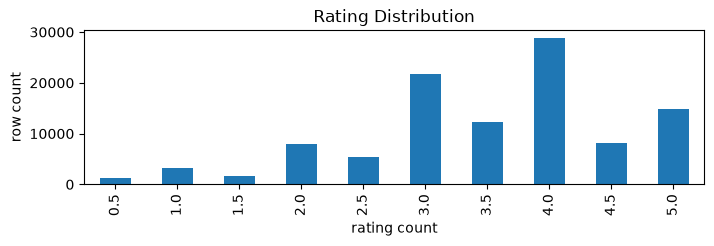

In [10]:
ratings_count.plot(kind="bar", figsize=(8,2))
plt.title("Rating Distribution")
plt.xlabel("rating count")
plt.ylabel("row count")
plt.show()

## 7. 사용자별 평점 개수

In [11]:
user_rating_count = (ratings.groupby("userId").size().reset_index(name="user_rating_count"))
print(user_rating_count)

     userId  user_rating_count
0         1                113
1         2                 29
2         3                 73
3         4                124
4         5                 68
..      ...                ...
663     664                 74
664     665                227
665     666                225
666     667                 74
667     668               5678

[668 rows x 2 columns]


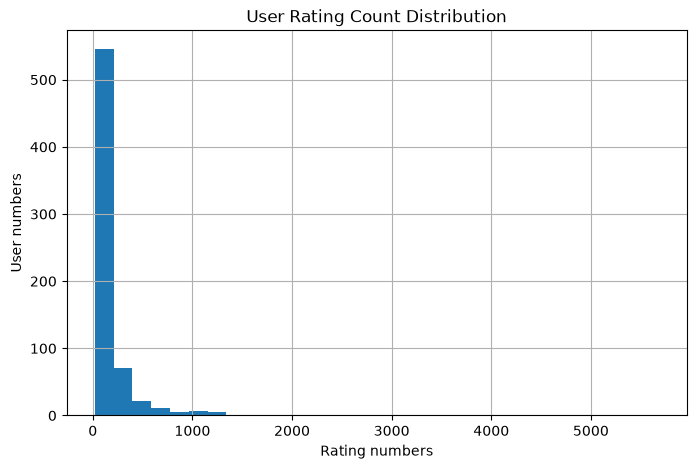

In [12]:
# 분포 확인
user_rating_count["user_rating_count"].hist(bins=30, figsize=(8,5))
plt.title("User Rating Count Distribution")
plt.xlabel("Rating numbers")
plt.ylabel("User numbers")
plt.show()

## 8. 영화별 평점 개수 Feature 생성

In [13]:
movie_rating_count = (ratings.groupby("movieId").size().reset_index(name="movie_rating_count"))
print(movie_rating_count)

       movieId  movie_rating_count
0            1                 232
1            2                  92
2            3                  58
3            4                  11
4            5                  62
...        ...                 ...
10320   146684                   1
10321   146878                   1
10322   148238                   1
10323   148626                   3
10324   149532                   1

[10325 rows x 2 columns]


In [14]:
# 영화별 평점 개수(movie_rating_count) + 영화(movies) 병합
movie_rating_count = movies.merge(movie_rating_count, on="movieId")
print(movie_rating_count)

       movieId                                title  \
0            1                     Toy Story (1995)   
1            2                       Jumanji (1995)   
2            3              Grumpier Old Men (1995)   
3            4             Waiting to Exhale (1995)   
4            5   Father of the Bride Part II (1995)   
...        ...                                  ...   
10320   146684        Cosmic Scrat-tastrophe (2015)   
10321   146878           Le Grand Restaurant (1966)   
10322   148238       A Very Murray Christmas (2015)   
10323   148626                 The Big Short (2015)   
10324   149532  Marco Polo: One Hundred Eyes (2015)   

                                            genres  movie_rating_count  
0      Adventure|Animation|Children|Comedy|Fantasy                 232  
1                       Adventure|Children|Fantasy                  92  
2                                   Comedy|Romance                  58  
3                             Comedy|Drama|Roma

In [15]:
# 평점 개수를 기준으로 인기 영화 추천
popular_movies = movie_rating_count.sort_values("movie_rating_count", ascending=False)
print(popular_movies.head(10))

      movieId                                      title  \
260       296                        Pulp Fiction (1994)   
316       356                        Forrest Gump (1994)   
279       318           Shawshank Redemption, The (1994)   
426       480                       Jurassic Park (1993)   
525       593           Silence of the Lambs, The (1991)   
230       260  Star Wars: Episode IV - A New Hope (1977)   
2056     2571                         Matrix, The (1999)   
522       589          Terminator 2: Judgment Day (1991)   
471       527                    Schindler's List (1993)   
98        110                          Braveheart (1995)   

                                genres  movie_rating_count  
260        Comedy|Crime|Drama|Thriller                 325  
316           Comedy|Drama|Romance|War                 311  
279                        Crime|Drama                 308  
426   Action|Adventure|Sci-Fi|Thriller                 294  
525              Crime|Horror|Thri

## 9. 영화별 평균 평점 Feature 생성

In [16]:
movie_rating_mean = (ratings.groupby("movieId")["rating"].mean().reset_index(name="movie_rating_mean"))
print(movie_rating_mean)

       movieId  movie_rating_mean
0            1           3.907328
1            2           3.353261
2            3           3.189655
3            4           2.818182
4            5           3.250000
...        ...                ...
10320   146684           4.000000
10321   146878           2.500000
10322   148238           3.000000
10323   148626           4.333333
10324   149532           4.000000

[10325 rows x 2 columns]


In [17]:
# movie_stats = 평점 개수 + 평균 평점 + 영화 정보
movie_stats = movie_rating_count.merge(movie_rating_mean, on="movieId")
print(movie_stats.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy                 232   
1                   Adventure|Children|Fantasy                  92   
2                               Comedy|Romance                  58   
3                         Comedy|Drama|Romance                  11   
4                                       Comedy                  62   

   movie_rating_mean  
0           3.907328  
1           3.353261  
2           3.189655  
3           2.818182  
4           3.250000  


In [18]:
# 평점이 높은 영화 정렬
high_rating_movies = movie_stats.sort_values("movie_rating_mean", ascending=False)
print(high_rating_movies)

       movieId                                          title  \
10296   140820                                     Air (2015)   
10281   139620             Everything's Gonna Be Great (1998)   
10279   139385                            The Revenant (2015)   
412        465                          Heaven & Earth (1993)   
8878     84716  Castaway on the Moon (Kimssi pyoryugi) (2009)   
...        ...                                            ...   
5513      7932                               Dark Days (2000)   
10314   143882                                Operator (2015)   
7238     50147                         Black Christmas (2006)   
7246     50445                            Hitcher, The (2007)   
7777     60382      Roman Polanski: Wanted and Desired (2008)   

                                genres  movie_rating_count  movie_rating_mean  
10296                  Sci-Fi|Thriller                   1                5.0  
10281  Adventure|Children|Comedy|Drama                   1 

In [19]:
# (1순위)평점 개수, (2순위)평균 평점이 높은 영화 정렬
high_rating_movies2 = movie_stats.sort_values(["movie_rating_count", "movie_rating_mean"], ascending=False)
print(high_rating_movies2)

       movieId                                              title  \
260        296                                Pulp Fiction (1994)   
316        356                                Forrest Gump (1994)   
279        318                   Shawshank Redemption, The (1994)   
426        480                               Jurassic Park (1993)   
525        593                   Silence of the Lambs, The (1991)   
...        ...                                                ...   
10138   120132                                       Annie (2014)   
10150   121308                      Goodbye to Language 3D (2014)   
10198   129701  The Aztec Mummy Against the Humanoid Robot (1958)   
10226   132157                      Paul Blart: Mall Cop 2 (2015)   
10314   143882                                    Operator (2015)   

                                 genres  movie_rating_count  movie_rating_mean  
260         Comedy|Crime|Drama|Thriller                 325           4.160000  
316      

In [20]:
# 기준 설정(1)
# 평가수(movie_rating_count)가 30개 이상인 영화를 기준
qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= 30]
print(qualified_movie.head(10))

    movieId                               title  \
0         1                    Toy Story (1995)   
1         2                      Jumanji (1995)   
2         3             Grumpier Old Men (1995)   
4         5  Father of the Bride Part II (1995)   
5         6                         Heat (1995)   
6         7                      Sabrina (1995)   
9        10                    GoldenEye (1995)   
10       11      American President, The (1995)   
15       16                       Casino (1995)   
16       17        Sense and Sensibility (1995)   

                                         genres  movie_rating_count  \
0   Adventure|Animation|Children|Comedy|Fantasy                 232   
1                    Adventure|Children|Fantasy                  92   
2                                Comedy|Romance                  58   
4                                        Comedy                  62   
5                         Action|Crime|Thriller                 115   
6           

In [21]:
# 기준 설정(2)
# 분위수 0.75 => 25%, 상위 25%에 해당하는 영화만 출력
# min_rating_count = movie_stats["movie_rating_count"].quantile(0.95)
# qualified_movie = movie_stats[movie_stats["movie_rating_count"] >= min_rating_count]
# print(qualified_movie)

## 10. 인기 영화 추천 함수

In [22]:
def recommend_popular_movie(top_n):
    result = (
        qualified_movie.sort_values("movie_rating_mean", ascending=False).head(top_n)
    )

    return result[
        [
            "movieId",
            "title",
            "movie_rating_count",
            "movie_rating_mean"
        ]
    ]

In [23]:
# 인기있는 영화 Top10
recommend_popular_movie(20)

,movieId,title,movie_rating_count,movie_rating_mean
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),37,4.459459
279,318,"Shawshank Redemption, The (1994)",308,4.454545
978,1217,Ran (1985),31,4.403226
744,923,Citizen Kane (1941),77,4.396104
695,858,"Godfather, The (1972)",210,4.392857
2398,3000,Princess Mononoke (Mononoke-hime) (1997),52,4.384615
1511,1945,On the Waterfront (1954),35,4.371429
725,904,Rear Window (1954),74,4.331081
47,50,"Usual Suspects, The (1995)",228,4.328947
1011,1252,Chinatown (1974),68,4.323529


## 11. 장르 데이터 이해

In [24]:
print(movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## 12. 장르 One-Hot Encoding

In [25]:
# str.get_dummies()
genre_feature = movies["genres"].str.get_dummies(sep="|")
print(genre_feature)

       (no genres listed)  Action  Adventure  Animation  Children  Comedy  \
0                       0       0          1          1         1       1   
1                       0       0          1          0         1       0   
2                       0       0          0          0         0       1   
3                       0       0          0          0         0       1   
4                       0       0          0          0         0       1   
...                   ...     ...        ...        ...       ...     ...   
10324                   0       0          0          1         1       1   
10325                   0       0          0          0         0       1   
10326                   0       0          0          0         0       1   
10327                   0       0          0          0         0       0   
10328                   1       0          0          0         0       0   

       Crime  Documentary  Drama  Fantasy  Film-Noir  Horror  IMAX  Musical

In [26]:
# movies에 genre_feature 컬럼 추가 - concat
movie_features = pd.concat(
    [
        movies[["movieId", "title", "genres"]],
        genre_feature
    ],
    axis=1
)
print(movie_features.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  (no genres listed)  Action  \
0  Adventure|Animation|Children|Comedy|Fantasy                   0       0   
1                   Adventure|Children|Fantasy                   0       0   
2                               Comedy|Romance                   0       0   
3                         Comedy|Drama|Romance                   0       0   
4                                       Comedy                   0       0   

   Adventure  Animation  Children  Comedy  Crime  ...  Film-Noir  Horror  \
0          1          1         1       1      0  ...          0       0   
1          1          0         1       0      0  ...          0       0   
2 

## 13. 코사인 유사도 불러오기

In [27]:
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
genre_columns = genre_feature.columns
print(genre_columns)

Index(['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='str')


In [33]:
# 영화간 유사도 계산하기
similarity_matrix = cosine_similarity(
    movie_features[genre_columns]
)
print(similarity_matrix.shape)
print(similarity_matrix)

(10329, 10329)
[[1.         0.77459667 0.31622777 ... 0.4472136  0.         0.        ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.70710678 0.         0.        ]
 ...
 [0.4472136  0.         0.70710678 ... 1.         0.         0.        ]
 [0.         0.         0.         ... 0.         1.         0.        ]
 [0.         0.         0.         ... 0.         0.         1.        ]]


In [ ]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index = movie_features['title'],
    columns=movie_features['title']
)
# print(similarity_df.head)
# similarity_df
similarity_df.iloc[:5, :5]

title,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Waiting to Exhale (1995),Father of the Bride Part II (1995)
title,,,,,
Toy Story (1995),1.000000,0.774597,0.316228,0.258199,0.447214
Jumanji (1995),0.774597,1.000000,0.000000,0.000000,0.000000
Grumpier Old Men (1995),0.316228,0.000000,1.000000,0.816497,0.707107
Waiting to Exhale (1995),0.258199,0.000000,0.816497,1.000000,0.577350
Father of the Bride Part II (1995),0.447214,0.000000,0.707107,0.577350,1.000000


## 14. 특정 영화 검색

In [39]:
# 1. 정확한 영화 제목 검색
movies[
    movies['title'].str.contains(
        'Toy Story',
        case = False,
        na = False
    )
]

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
8599,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


In [42]:
# 2. DF에서 검색한 영화의 인덱스 찾기
movie_index = movies[
    movies['title'] == 'Toy Story (1995)'
].index[0]
print(movie_index)

0


In [43]:
# 3. 검색한 영화와 유사한 영화를 가져옴
similarity_scores = list(
    enumerate(similarity_matrix[movie_index])
)
print(similarity_scores)

[(0, np.float64(0.9999999999999999)), (1, np.float64(0.7745966692414835)), (2, np.float64(0.3162277660168379)), (3, np.float64(0.25819888974716115)), (4, np.float64(0.4472135954999579)), (5, np.float64(0.0)), (6, np.float64(0.3162277660168379)), (7, np.float64(0.6324555320336758)), (8, np.float64(0.0)), (9, np.float64(0.25819888974716115)), (10, np.float64(0.25819888974716115)), (11, np.float64(0.3162277660168379)), (12, np.float64(0.7745966692414835)), (13, np.float64(0.0)), (14, np.float64(0.25819888974716115)), (15, np.float64(0.0)), (16, np.float64(0.0)), (17, np.float64(0.4472135954999579)), (18, np.float64(0.4472135954999579)), (19, np.float64(0.19999999999999998)), (20, np.float64(0.25819888974716115)), (21, np.float64(0.0)), (22, np.float64(0.0)), (23, np.float64(0.0)), (24, np.float64(0.0)), (25, np.float64(0.0)), (26, np.float64(0.3162277660168379)), (27, np.float64(0.0)), (28, np.float64(0.39999999999999997)), (29, np.float64(0.0)), (30, np.float64(0.0)), (31, np.float64(0.0

In [ ]:
# 4. 상위 영화 기준으로 정렬
similarity_scores = sorted(
    similarity_scores,
    key=lambda x: x[1],
    reverse=True
)

In [45]:
# 5. 상위 10개 추출 - 첫 번째는 자기 자신이므로 제외
scores = similarity_scores[1:11]
print(scores)

[(1815, np.float64(0.9999999999999999)), (2496, np.float64(0.9999999999999999)), (2967, np.float64(0.9999999999999999)), (3166, np.float64(0.9999999999999999)), (3811, np.float64(0.9999999999999999)), (6617, np.float64(0.9999999999999999)), (6997, np.float64(0.9999999999999999)), (7382, np.float64(0.9999999999999999)), (7987, np.float64(0.9999999999999999)), (9215, np.float64(0.9999999999999999))]


In [46]:
# 6. 추천 영화 인덱스 추출
recommend_indexes = [
    index for index, score in scores
]
movies.iloc[recommend_indexes]

,movieId,title,genres
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy


## 14. 컨텐츠 기반 추천 함수

In [47]:
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies['title'].str.lower() == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]})

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 유사한 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력(자신 제외)
    similarity_scores = similarity_scores[1:top_n+1]

    # 6. 추천 영화 인덱스 추출
    recommend_indexs = [
        index for index, score in similarity_scores
    ]

    # 7. 추천 영화 컨텐츠 가져오기
    recommendations = movies.iloc[
        recommend_indexs
    ][
        ['movieId', 'title', 'genres']
    ].copy()

    recommendations['similarity_score'] = [
        score for index, score in similarity_scores
    ]

    return recommendations

In [49]:
recommend_similar_movies('Toy Story (1995)', 10)

,movieId,title,genres,similarity_score
1815,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.0
2496,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.0
2967,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3166,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.0
3811,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.0
6617,33463,DuckTales: The Movie - Treasure of the Lost La...,Adventure|Animation|Children|Comedy|Fantasy,1.0
6997,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,1.0
7382,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.0
7987,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,1.0
9215,91355,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy,1.0


## 15. 컨텐츠 기반 함수 추천 결과 + 협업 필터링 추가(아이템 기반)

컨텐츠만 비슷한 영화 중 평가가 없다면 신뢰가 부족한다 => 평가 아이템을 추가하여 신뢰도를 높임

In [53]:
movie_result_data = movies.merge(
    movie_stats[
        [
            'movieId',
            'movie_rating_count',
            'movie_rating_mean'
        ]
    ],
    on = 'movieId',
    how = 'left'
)
print(movie_result_data.head())
print(movie_result_data.shape)

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  movie_rating_count  \
0  Adventure|Animation|Children|Comedy|Fantasy               232.0   
1                   Adventure|Children|Fantasy                92.0   
2                               Comedy|Romance                58.0   
3                         Comedy|Drama|Romance                11.0   
4                                       Comedy                62.0   

   movie_rating_mean  
0           3.907328  
1           3.353261  
2           3.189655  
3           2.818182  
4           3.250000  
(10329, 5)


In [ ]:
# 컨텐츠 기반 추천 함수에 movie_result_data를 통해 필터링 작업 수행
# 컨텐츠 기반 함수 수정
def recommend_similar_movies(title, top_n):
    matched_movies = movies[
        movies['title'].str.lower() == title.lower()
    ]

    if matched_movies.empty:
        return pd.DataFrame({"message": ["영화를 찾을 수 없습니다."]})

    movie_index = matched_movies.index[0]

    # 3. 검색한 영화와 유사한 영화를 가져옴
    similarity_scores = list(
        enumerate(similarity_matrix[movie_index])
    )

    # 4. 상위 영화 기준으로 정렬
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # 5. 상위 10개 출력(자신 제외)
    similarity_scores = similarity_scores[1:]

    ## 아이템(rating) 기준 협업 필터링 Start
    results = []

    for index, score in similarity_scores:
        movie = movie_result_data.iloc[index]
        if movie['movie_rating_count'] >= 10:
            results.append(
                {
                    'movieId': movie['movieId'],
                    'title' : movie['title'],
                    'genres' : movie['genres'],
                    'similarity_score' : round(score, 2),
                    'rating_count' : int(movie['movie_rating_count']),
                    'rating_mean' : int(movie['movie_rating_mean'])
                }
            )

        if len(results) == top_n:
            break

    ## 아이템(rating) 기준 협업 필터링 End
    return pd.DataFrame(results)

In [55]:
recommend_similar_movies('Toy Story (1995)', 10)

,movieId,title,genres,similarity_score,rating_count,rating_mean
0,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,1.00,57,3
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1.00,104,3
2,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,1.00,24,3
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,1.00,116,3
4,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,1.00,15,2
5,673,Space Jam (1996),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.91,48,2
6,4306,Shrek (2001),Adventure|Animation|Children|Comedy|Fantasy|Ro...,0.91,158,3
7,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.91,35,4
8,108932,The Lego Movie (2014),Action|Adventure|Animation|Children|Comedy|Fan...,0.91,17,3
9,1848,"Borrowers, The (1997)",Adventure|Children|Comedy|Fantasy,0.89,10,3
